<a href="https://colab.research.google.com/github/100522128/g81_P2_03_Aprendizaje_Automatico/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 2 - Determinacion Grupos de Estrellas
**Miembros del grupo:**

Christian Cano -> 100522320

Adrián Curell -> 100522128

[Repositorio de github](https://github.com/100522128/g81_P2_03_Aprendizaje_Automatico.git)

##1 Visualización de los datos

###1.1 Carga del dataset

Cargamos el archivo “starts_data.csv" usando pandas

In [ ]:
import pandas as pd
from google.colab import files
archivos = files.upload()
df=pd.read_csv("stars_data.csv")

Saving stars_data.csv to stars_data.csv


###1.2 Tipos de variables

Ahora clasificamos las variables segun su tipo

In [ ]:
print(df.dtypes.values)

[dtype('int64') dtype('float64') dtype('float64') dtype('float64')
 dtype('O') dtype('O')]


Como podemos ver todas son o int64/float64 o Object por lo que podemos hacer un clasificador automático que las separe en numéricas (int64/float64) o no numéricas (Object), que se dividirá en categóricas o ordinales.

**En este caso todas serán ordinales.*

Para realizarlo haremos:

1. Dividir las variables en numéricas o no numéricas según su dtype utilizando la función select_dtypes.

2. De las no numéricas sacamos con unique los distintos valores que tienen y con nunique el numero total.

3. Creamos una lista para el tipo (numéricas o ordinales).

4. Recorrer el dataframe con un bucle y rellenando estas listas con los datos de las variables.

5. Crear un dataframe donde introduzcamos los datos de estas listas juntos al nombre y dtype de cada variable.

In [ ]:
import numpy as np

# Clasificación automática de variables
variables_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
variables_no_numericas = df.select_dtypes(include=['object']).columns.tolist()

N_unique = []
Valores = []

for i in variables_no_numericas:
  N_unique.append(df[i].nunique())
  Valores.append(df[i].unique())

cardinalidad = pd.DataFrame({
    'Variable': variables_no_numericas,
    'N_unique': N_unique,
    'Valores': Valores
})
print(cardinalidad[['Variable', 'N_unique', 'Valores']].to_string(index=False))

variables_ordinales = []
variables_ordinales = variables_no_numericas.copy()

# Imprimimos la clasificación
print('\n=== Variables NUMÉRICAS ===')
print(variables_numericas)

print('\n=== Variables ORDINALES ===')
print(variables_ordinales)

# Creamos listas vacías donde almacenar los tipos y roles de cada variable
lista_tipo = []

# Recorrer columnas
for c in df.columns:
  # Tipo (Numérica o Ordinal)
  if c in variables_numericas:
    lista_tipo.append('Numérica')
  else:
    lista_tipo.append('Ordinal')


# Crear DataFrame final
resumen_tipos = pd.DataFrame({
    'Variable': df.columns,
    'Dtype': df.dtypes.values,
    'Tipo': lista_tipo,
})

print('\n', resumen_tipos.to_string(index=True))

      Variable  N_unique                                                                                                                                                                                       Valores
         Color        17 [Red, Blue White, White, Yellowish White, Blue white, Pale yellow orange, Blue, Blue-white, Whitish, yellow-white, Orange, White-Yellow, white, yellowish, Yellowish, Orange-Red, Blue-White]
Spectral_Class         7                                                                                                                                                                         [M, B, A, F, O, K, G]

=== Variables NUMÉRICAS ===
['Temperature', 'L', 'R', 'A_M']

=== Variables ORDINALES ===
['Color', 'Spectral_Class']

          Variable    Dtype      Tipo
0     Temperature    int64  Numérica
1               L  float64  Numérica
2               R  float64  Numérica
3             A_M  float64  Numérica
4           Color   object   Ordinal
5  Spectral_

Vemos que son variables ordinales Color y Spectral_Class, siendo el resto variables numericas

###1.3 Valores faltantes

Ahora comprobamos si hay valores faltantes en alguna variable

In [ ]:
faltan = pd.DataFrame({
    'Variable': df.columns,
    'Valores faltantes': df.isnull().sum().values,
    '% faltantes': (df.isnull().mean() * 100).round(2).values
})
faltan = faltan[faltan['Valores faltantes'] > 0]

if faltan.empty:
    print('No hay valores faltantes (NaN) en el dataset.')
else:
    print('Variables con valores faltantes:')
    print(faltan.to_string(index=False))

No hay valores faltantes (NaN) en el dataset.


Tras la comprobacion se puede afirmar que no existen valores faltantes por lo que podemos pasar al tratamiento de las variables ordinales directamente

###1.4 Conversión de variables ordinales

En esta etapa del preprocesado, se procedió a la transformación de las variables cualitativas Color y Spectral_Class en magnitudes numéricas mediante un mapeo ordinal. Esta decisión técnica se fundamenta en que ambas variables poseen una jerarquía física intrínseca vinculada a la termodinámica estelar.


Variable Color: Se estableció una escala numérica donde el valor mínimo ($0$) se asignó a las longitudes de onda asociadas a menores temperaturas (colores cálidos como el rojo) y el valor máximo a las estrellas de mayor temperatura superficial (colores de alta energía como el azul).

Variable Spectral_Class: Se aplicó una lógica análoga siguiendo estrictamente la secuencia térmica proporcionada en las directrices de la práctica: (O, B, A, F, G, K, M). En este modelo, las estrellas de tipo M (más frías) representan el extremo inferior de la escala, mientras que las de tipo O (más calientes) definen el extremo superior, preservando así la relación de energía necesaria para el análisis de clustering posterior.

Esta codificación permite que los algoritmos de aprendizaje no supervisado interpreten correctamente la proximidad física entre los diferentes tipos de estrellas, factor que se perdería con otras técnicas como el one-hot encoding.

In [ ]:
# 1. Configuración inicial
SEMILLA = 100522320
np.random.seed(SEMILLA)

def transformar_ordinales(X_in):
    X_df = X_in.copy()

    # Diccionarios de mapeo basados en criterios térmicos
    spectral_map = {'o': 6, 'b': 5, 'a': 4, 'f': 3, 'g': 2, 'k': 1, 'm': 0}
    color_map = {
        'red': 0, 'orange red': 1, 'orange': 2, 'pale yellow orange': 3,
        'yellowish': 4, 'yellowish white': 5, 'yellow white': 5,
        'white yellow': 5, 'whitish': 6, 'white': 7, 'blue white': 8, 'blue': 9
    }

    # Limpieza de texto y aplicación de mapeo
    X_df['Spectral_Class'] = X_df['Spectral_Class'].str.lower().map(spectral_map)
    X_df['Color'] = X_df['Color'].str.lower().str.replace('-', ' ').str.strip().map(color_map)

    return X_df

## 2 PCA

Para que sea más sencillo visualizar los datos vamos a usar PCA con los 2 componentes principales. Lo primero será visualizar la varianza explicada acumulada, que como se puede observar, con solo 4 componentes se explica más del 96% de la varianza y con 2 podemos explicar hasta un 85%.

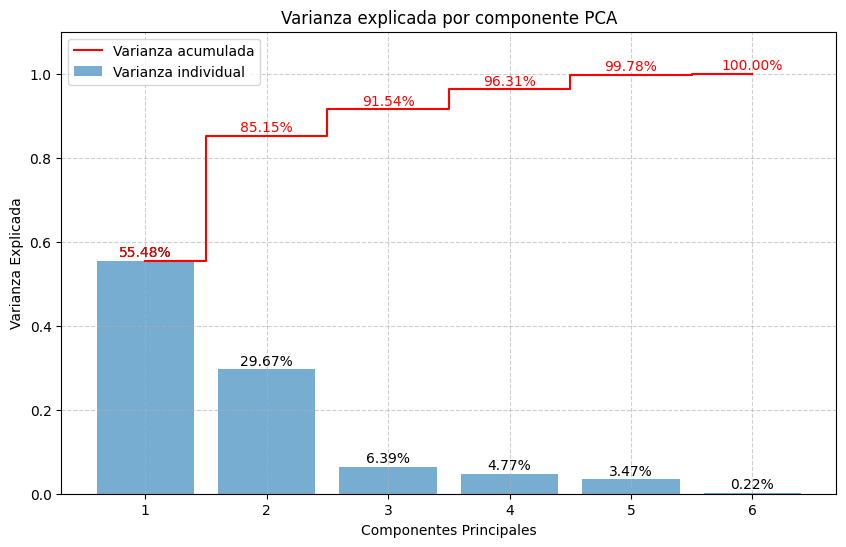

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer

# Definimos el paso de transformación de las ordinales usando FunctionTransformer
paso_ordinal = FunctionTransformer(transformar_ordinales)

# Creamos el Pipeline de PCA
pipeline_pca = Pipeline([
    ('limpieza_ordinal', paso_ordinal),
    ('escalador', StandardScaler()),
    ('pca', PCA())
])

# Ajustar y transformar
X_pca = pipeline_pca.fit_transform(df)
pca = pipeline_pca.named_steps['pca']

# Varianza explicada y acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot de Varianza Explicada y Acumulada
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, label='Varianza individual')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Varianza acumulada', color='red')

# Añadir valores exactos
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    plt.text(i + 1, ev + 0.01, f"{ev:.2%}", ha='center')
    plt.text(i + 1, cv + 0.01, f"{cv:.2%}", ha='center', color='red')

plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Varianza explicada por componente PCA')
plt.legend(loc='best')
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Ahora, nos quedaremos con los 2 componentes más importantes, como explica el enunciado:

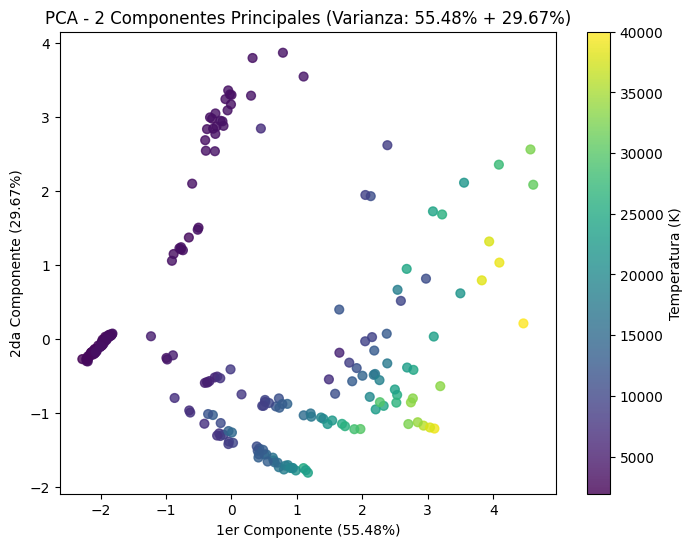

In [ ]:
# Pipeline de PCA
pipeline_pca = Pipeline([
    ('limpieza_ordinal', paso_ordinal),
    ('escalador', StandardScaler()),
    ('pca', PCA(n_components=2))
])

# Ajustar y transformar
X_pca = pipeline_pca.fit_transform(df)
pca = pipeline_pca.named_steps['pca']

# Visualizar
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Temperature'], s=40, cmap='viridis', alpha=0.8)
plt.title('PCA - 2 Componentes Principales (Varianza: {:.2%} + {:.2%})'.format(explained_variance[0], explained_variance[1]))
plt.xlabel('1er Componente ({:.2%})'.format(explained_variance[0]))
plt.ylabel('2da Componente ({:.2%})'.format(explained_variance[1]))
plt.colorbar(label='Temperatura (K)')
plt.show()

## 3 K-Means

En esta sección aplicaremos el algoritmo K-Means sobre las 2 componentes principales obtenidas mediante PCA. Para determinar el número óptimo de clusters ($k$), evaluaremos un rango de posibles agrupaciones (de 2 a 10) utilizando dos métricas clave:

1. **Inercia (Método del Codo):** Mide la suma de las distancias al cuadrado de las muestras a su centroide más cercano. Buscamos el punto donde la curva forma un "codo", indicando que añadir más clusters no mejora significativamente la varianza explicada.
2. **Silhouette Score:** Mide cuán similar es un objeto a su propio cluster en comparación con otros clusters. Varía de -1 a 1, donde valores más altos indican agrupaciones mejor definidas.

Tras analizar estas métricas, elegiremos el $k$ óptimo, entrenaremos el modelo final y visualizaremos la distribución espacial de los clusters.

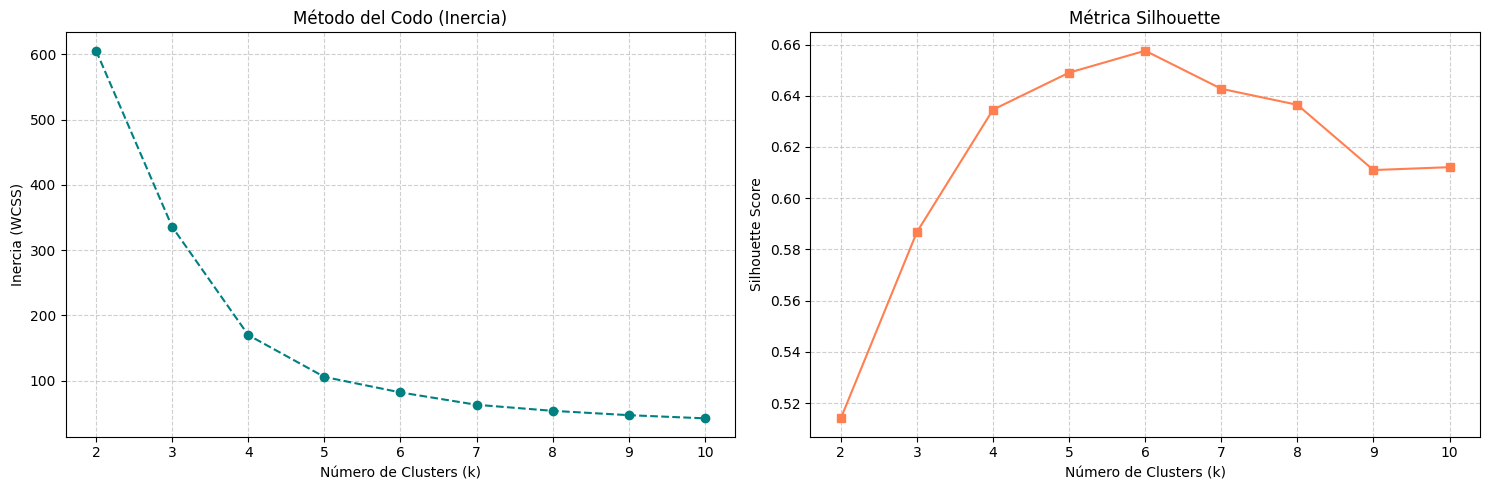

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Definimos el rango de clusters a probar
rango_k = range(2, 11) # de 2 a 10 centroides
inercias = []
silhouette_scores = []

# Iteramos para calcular métricas por cada valor de k
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10)
    etiquetas = kmeans.fit_predict(X_pca)

    inercias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, etiquetas))

# Configuración de los gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Método del Codo
ax1.plot(rango_k, inercias, marker='o', linestyle='--', color='teal')
ax1.set_title('Método del Codo (Inercia)')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Silhouette Score
ax2.plot(rango_k, silhouette_scores, marker='s', linestyle='-', color='coral')
ax2.set_title('Métrica Silhouette')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 3.1 Decisión del hiperparámetro $k$ y Modelo Final

Al analizar las métricas generadas, podemos extraer conclusiones muy claras para elegir nuestro número óptimo de clusters:

1. **Método del Codo (Inercia):** Observamos que la suma de las distancias al cuadrado (WCSS) disminuye drásticamente hasta $k=4$, punto a partir del cual la curva comienza a aplanarse. Si bien el "codo" visual podría sugerir 4 o 5 clusters, la inercia en $k=6$ es baja y se encuentra en la zona de estabilización.
2. **Silhouette Score:** Esta métrica resulta determinante para nuestro caso. La gráfica muestra una tendencia ascendente que culmina en un **pico máximo muy evidente en $k=6$** (alcanzando un valor cercano a 0.66). Esto indica que al dividir los datos en 6 grupos obtenemos la máxima cohesión dentro de cada cluster y la mejor separación frente al resto.

**Conclusión:**
Las métricas respaldan la elección de **$k=6$**. Cabe destacar, que este valor coincide de forma exacta con la naturaleza física del problema, ya que la tabla de referencia del enunciado clasifica a estas estrellas en **6 tipos principales** (Enana roja, Enana marrón, Enana blanca, Estrella en secuencia principal, Super gigante e Hiper gigante).

Por tanto, procedemos a entrenar nuestro modelo final de K-Means fijando $k=6$.

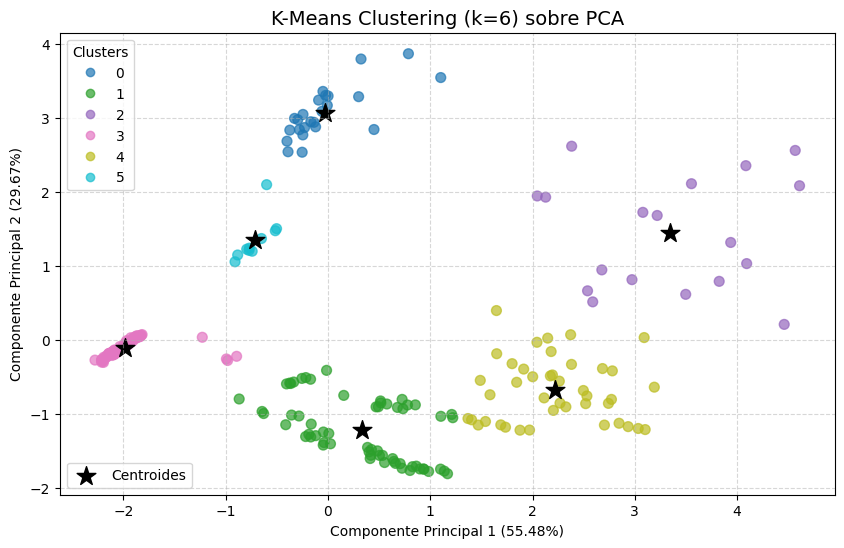

In [35]:
# Elegimos el hiperparámetro k óptimo
k_optimo = 6

# Entrenamos el modelo final
kmeans_final = KMeans(n_clusters=k_optimo, random_state=SEMILLA, n_init=10)
etiquetas_kmeans = kmeans_final.fit_predict(X_pca)

# Guardamos las etiquetas en el dataframe original para el análisis posterior
df['Cluster_KMeans'] = etiquetas_kmeans

# Visualización del clustering final
plt.figure(figsize=(10, 6))

# Dibujar los puntos coloreados por cluster
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=etiquetas_kmeans, cmap='tab10', s=50, alpha=0.7)

# Dibujar los centroides
centroides = kmeans_final.cluster_centers_
plt.scatter(centroides[:, 0], centroides[:, 1],
            c='black', marker='*', s=200, edgecolor='black', label='Centroides')

plt.title(f'K-Means Clustering (k={k_optimo}) sobre PCA', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({explained_variance[0]:.2%})')
plt.ylabel(f'Componente Principal 2 ({explained_variance[1]:.2%})')

# Crear leyenda para los clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters", loc='upper left')
plt.gca().add_artist(legend1)
plt.legend(loc='lower left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4 Hierarchical Clustering

## 5 DBSCAN